The PDF file doesn't express the goal of the project clearly. We restate it here:

We observed historical 1-minute futures OHLCV data. We can resample it into x-minute data as long as x divides 60. For a chosen horizon $\tau=5,10,\dots$, we estimate the empirical distribution of future upward and downward price excursions, either unconditionally or condistional on the current volatility-volume-trend regime. These distributions are then used to determine where to place limit orders, so as to maximize expected execution quality by balancing fill probability against price improvement. The resulting rule is then backtested and compared with a benchmark, such as the reconstructed PnL of the market maker form the "AIAgent_xxx" files.

At time $t$, let the current reference price (open price) be $x_t$ and the tick size be $\epsilon$

If we want to buy, candidiate limit prices are:
$$
p_k^{buy}=x_t-k\epsilon, \quad k=0,1,2,\dots
$$

If we want to sell, candidiate limit prices are:
$$
p_k^{sell}=x_t+k\epsilon, \quad k=0,1,2,\dots
$$

Here $k$ is the aggressiveness/passiveness choice:

- small $k$: closer to market, easier fill, worse price

- large $k$: better price, lower fill probability.


For a buy order at $x_t-k\epsilon$, you get filled if the future low falls at least $k$ ticks below the open,
$$
R_{t,\tau}^{(D)} \ge k \epsilon
$$

So,
$$
P(\text{buy fill at k})=P\left( R_{t,\tau}^{(D)} \ge k\epsilon \mid \text{state}_t \right)
$$

Similarly, for a sell order at $x_t+k\epsilon$,
$$
P(\text{sell fill at k})=P\left( R_{t,\tau}^{(U)} \ge k\epsilon \mid \text{state}_t \right)
$$

If unconditional:
$$
P(\text{buy fill at k})=P\left( R_{t,\tau}^{(D)} \ge k\epsilon \right)
$$
$$
P(\text{sell fill at k})=P\left( R_{t,\tau}^{(U)} \ge k\epsilon \right)
$$


Now we need to determine how to choose $k$. Before proceeding, noet an implicit assumption above: **we don't split orders.**

For example, during the interval $[t, t+\tau)$, suppose we want to sell 5 units. The above method places all 5 units at a single price level $p_k^{sell}$. Alternatively, we could split the order across multiple levels (e.g. 2 units at $p_{k-1}^{sell}$, 2 units at $p_{k}^{sell}$, and 1 units at $p_{k+1}^{sell}$).

Since the second approach is significantly more complex, we focus on the first case: no order splitting.

Another requirment is to match the net position of the market maker in AIAgent data. Since $\tau=5$ in the agent data, if we also use $\tau=5$, we must ensure that our position changes within each interval and the net position at each timestamp are identical to those of the market maker. This implies the following:

- If we want to sell at $p_k^{sell}$, but $R_{t,\tau}^{(D)}<k$, the order is not filled. We then execute the order using a market order at the close price $c_t$.

- If we want to buy at $p_k^{buy}$, but $R_{t,\tau}^{(U)}<k$, the order is not filled. We then execute using a market order at $c_t$.

Therefore,the expected cash flow over the interval $[t,t+\tau)$ is
$$
\text{buy q units}: \quad - \left[ P\left( R_{t,\tau}^{(D)} \ge k\epsilon \mid \text{state}_t \right) p_k^{buy} +P\left( R_{t,\tau}^{(D)} < k\epsilon \mid \text{state}_t \right) c_t \right] q
$$
$$
\text{sell q units}: \quad \left[ P\left( R_{t,\tau}^{(U)} \ge k\epsilon \mid \text{state}_t \right) p_k^{sell} +P\left( R_{t,\tau}^{(U)} < k\epsilon \mid \text{state}_t \right) c_t \right] q
$$

For the market maker, the cash flow is approximated as:
$$
\text{buy q units}: \quad -\frac{x_t+x_{t+1}}{2} q
$$
$$
\text{sell q units}: \quad \frac{x_t+x_{t+1}}{2} q
$$

Since the net position is identical at each timestamp, the PnL component from inventory (mark-to-market) is the same. Therefore, **outperformance comes from achieving higher cumulative cash flow.**


However, in practice, the futures data and agent data are not perfectly aligned:

- Although timestamps match, the futures open price $x_t$ differs from the agent price $x_t'$

- In about 10% of observations, the agent price even lies outside the futures high-low range

Therefore, the correct market maker cash flow should be:
$$
\text{buy q units}: \quad -\frac{x_t'+x_{t+1}'}{2} q
$$
$$
\text{sell q units}: \quad \frac{x_t'+x_{t+1}'}{2} q
$$
where $x'$ is the price from the agent data, and $x_t' \neq x_t$.

There is also an inconsistency in inventory valuation:

- Using futures data: $\text{net position}_t x_t$

- Using agent data: $\text{net position}_t x_t'$

These should theoretically be the same, but they are not. What we choose to use futures prices to value inventory: $\text{net position}_t x_t$.

In essence, the true difference lies in cumulative cash flow, but this series is noisy and difficult to interpret directly. Instead, we compare the full PnL curve, which is smoother. ALthough the inventory component is identical, the difference in cash flow is reflected clearly in the overall PnL.

# **Trading Rules (How to choose $k$)**

### **Rule 1: Fill-probability threshold**

Suppose we already know we want to but.

For each $k$, compute
$$
P_k^{buy}=P(R_{t,\tau}^{(D)}\ge k\epsilon \mid \text{state}_t)
$$

The choose the deepest level satisfying
$$
P_k^{buy} \ge p^*
$$
for some threshold like $p^*=0.6,0.7$.

### **Rule 2: Expected-price-improvement rule**

For each $k$, define
$$
\text{score}_k^{buy}=P_k^{buy} \cdot k\epsilon
$$
$$
\text{score}_k^{sell}=P_k^{sell} \cdot k\epsilon
$$

choose $k$ that maximizes the score.

This treats $k$ as the price improvement, weighted by fill probability.

### **Rule 3: Expected PnL rule**

Estimate, from historical data in the same state:

- probability of fill at level $k$

- average terminal move after such a fill $p_k^{sell}-x_{t+1}$ for sell and $x_{t+1}-p_k^{buy}$ for buy

Then choose $k$ maximizing expected PnL net of costs:
$$
\text{EV}_k = P(\text{fill}_k) \times \text{Avg payoff after fill}_k - \text{fees/slippage}
$$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath(".."))
from src.utils.paths import RAW_DATA_DIR, DATA_DIR

In [2]:
futures_path=DATA_DIR/'futures'/'minute_5'
agent_path=DATA_DIR/'agent'

market='Nasdaq'

# agent
agent_data=pd.read_parquet(agent_path/f'{market}.parquet')
agent_data['trade']=agent_data['position'].diff().fillna(0)
agent_data.set_index('time',inplace=True)

# futures data
data=pd.read_parquet(futures_path/f'{market}.parquet')
data.set_index('time',inplace=True)

# calculate range
tick_size=0.25
data['range']=((data['high']-data['low'])/tick_size).astype(int)
data['range_u']=((data['high']-data['open'])/tick_size).astype(int)
data['range_d']=((data['open']-data['low'])/tick_size).astype(int)

print(f'max k of range: {data['range'].max()}')
print(f'max k of range_U: {data['range_u'].max()}')
print(f'max k of range_D: {data['range_d'].max()}')

# trading time
trading_time_list=[pd.Timestamp(t) for t in agent_data.index]
data=data.loc[:trading_time_list[-1]].copy()
print(f'futures data start time: {pd.Timestamp(data.index[0])}')
print(f'futures data end time: {pd.Timestamp(data.index[-1])}')
print(f'trading start time: {trading_time_list[0]}')
print(f'traing end time: {trading_time_list[-1]}')

max k of range: 1349
max k of range_U: 905
max k of range_D: 1348
futures data start time: 2019-12-13 00:00:00
futures data end time: 2020-05-29 22:55:00
trading start time: 2020-01-02 06:00:00
traing end time: 2020-05-29 23:00:00


In [3]:
print(agent_data.shape[0])
agent_data.head()

27921


,date,hour,minute,price,position,trade
time,,,,,,
2020-01-02 06:00:00,2020-01-02,0,0,8787.75,0,0.0
2020-01-02 06:05:00,2020-01-02,0,5,8787.75,0,0.0
2020-01-02 06:10:00,2020-01-02,0,10,8786.00,0,0.0
2020-01-02 06:15:00,2020-01-02,0,15,8785.50,0,0.0
2020-01-02 06:20:00,2020-01-02,0,20,8785.25,0,0.0


In [4]:
print(len(data.loc[trading_time_list[0]:]))
data.head()

27959


,open,high,low,close,volume,date,contract,n_rows,range,range_u,range_d
time,,,,,,,,,,,
2019-12-13 00:00:00,8508.00,8521.50,8508.00,8518.00,625.0,2019-12-13,0,1.0,54,54,0
2019-12-13 00:05:00,8517.50,8524.25,8517.50,8522.75,680.0,2019-12-13,0,1.0,27,27,0
2019-12-13 00:10:00,8522.50,8523.25,8521.00,8521.50,163.0,2019-12-13,0,1.0,9,3,6
2019-12-13 00:15:00,8521.25,8521.25,8517.50,8518.50,322.0,2019-12-13,0,1.0,15,0,15
2019-12-13 00:20:00,8519.00,8521.50,8517.75,8518.25,181.0,2019-12-13,0,1.0,15,10,5


In [5]:
# prepare period
prepare_mask=data.index<trading_time_list[0]
prepare_data=data.loc[prepare_mask]

hist_d=np.bincount(prepare_data['range_d'],minlength=int(data['range_d'].max())+1)
hist_u=np.bincount(prepare_data['range_u'],minlength=int(data['range_u'].max())+1)
hist_r=np.bincount(prepare_data['range'],minlength=int(data['range'].max())+1)

cnt=len(prepare_data)
print(f'prepare sample size: {cnt}')


prepare sample size: 3317


In [6]:
def choose_k_from_hist(
    hist: np.ndarray,
    cnt: int,
    p_star: float
)->int:
    """
    Choose the largest k such that P(X >= k) >= p_star.
    """
    
    if cnt==0:
        return 0
    
    tail_counts=np.cumsum(hist[::-1])[::-1]
    tail_probs=tail_counts/float(cnt)
    
    valid_k=np.where(tail_probs>=p_star)[0]
    if len(valid_k)==0:
        return 0
    
    return int(valid_k.max())
    
    
p_star=0.7

results=[]

for t,row in data.loc[trading_time_list[0]:].iterrows():
    t=pd.Timestamp(t)
    
    if t in trading_time_list:
        open_price=data.loc[t,'open']
        q=agent_data.loc[t,'trade']
        if q>0:
            k=choose_k_from_hist(hist_d,cnt,p_star)
            p=open_price-k*tick_size
            flag=1 # buy
        elif q<0:
            k=choose_k_from_hist(hist_u,cnt,p_star)
            p=open_price+k*tick_size
            flag=-1 # sell
        else:
            k=None
            p=None
            flag=None
            
        results.append({
            'time':t,
            'k':k,
            'target_price':p,
            'target_amount':q
        })
        
    d = int(row['range_d'])
    u = int(row['range_u'])
    r = int(row['range'])

    hist_d[d] += 1
    hist_u[u] += 1
    hist_r[r] += 1
    cnt += 1
    
results=pd.DataFrame(results).set_index('time')
print(set(results.index).issubset(set(agent_data.index)))
print(results.shape[0])
results.head()

True
26472


,k,target_price,target_amount
time,,,
2020-01-02 06:00:00,NaN,NaN,0.0
2020-01-02 06:05:00,NaN,NaN,0.0
2020-01-02 06:10:00,NaN,NaN,0.0
2020-01-02 06:15:00,NaN,NaN,0.0
2020-01-02 06:20:00,NaN,NaN,0.0


In [7]:
agent_data['cash']=(-(agent_data['trade']*(agent_data['price'].shift()+agent_data['price'])/2).fillna(0)).astype(float)# middle price
agent_data['inventory']=agent_data['position']*agent_data['price']

df=pd.concat([results,
              agent_data[['price','position','trade','cash','inventory']],
              data[['open','close','high','low']]],axis=1,join='inner')
print(df.shape[0])
df.head()

26472


,k,target_price,target_amount,price,position,trade,cash,inventory,open,close,high,low
time,,,,,,,,,,,,
2020-01-02 06:00:00,NaN,NaN,0.0,8787.75,0,0.0,-0.0,0.0,8787.75,8787.75,8788.25,8787.25
2020-01-02 06:05:00,NaN,NaN,0.0,8787.75,0,0.0,-0.0,0.0,8787.75,8786.00,8787.75,8786.00
2020-01-02 06:10:00,NaN,NaN,0.0,8786.00,0,0.0,-0.0,0.0,8786.00,8785.50,8786.75,8785.50
2020-01-02 06:15:00,NaN,NaN,0.0,8785.50,0,0.0,-0.0,0.0,8785.50,8785.25,8786.75,8784.50
2020-01-02 06:20:00,NaN,NaN,0.0,8785.25,0,0.0,-0.0,0.0,8785.25,8784.50,8785.25,8784.50


In [21]:
df['cash_new']=0.0

for i in range(len(df)):
    row=df.iloc[i]
    
    if row['target_amount']>0:
        if row['target_price']>=row['low']:
            df.loc[row.name, 'cash_new']=-row['target_amount']*row['target_price']
        else:
            df.loc[row.name, 'cash_new']=-row['target_amount']*row['close']
    elif row['target_amount']<0:
        if row['target_price']<=row['high']:
            df.loc[row.name, 'cash_new']=-row['target_amount']*row['target_price']
        else:
            df.loc[row.name, 'cash_new']=-row['target_amount']*row['close']

df['position']=df['target_amount'].cumsum()
df['inventory']=df['position']*df['close']      
df.head()

,k,target_price,target_amount,price,position,trade,cash,inventory,open,close,high,low,cash_new
time,,,,,,,,,,,,,
2020-01-02 06:00:00,NaN,NaN,0.0,8787.75,0.0,0.0,-0.0,0.0,8787.75,8787.75,8788.25,8787.25,0.0
2020-01-02 06:05:00,NaN,NaN,0.0,8787.75,0.0,0.0,-0.0,0.0,8787.75,8786.00,8787.75,8786.00,0.0
2020-01-02 06:10:00,NaN,NaN,0.0,8786.00,0.0,0.0,-0.0,0.0,8786.00,8785.50,8786.75,8785.50,0.0
2020-01-02 06:15:00,NaN,NaN,0.0,8785.50,0.0,0.0,-0.0,0.0,8785.50,8785.25,8786.75,8784.50,0.0
2020-01-02 06:20:00,NaN,NaN,0.0,8785.25,0.0,0.0,-0.0,0.0,8785.25,8784.50,8785.25,8784.50,0.0


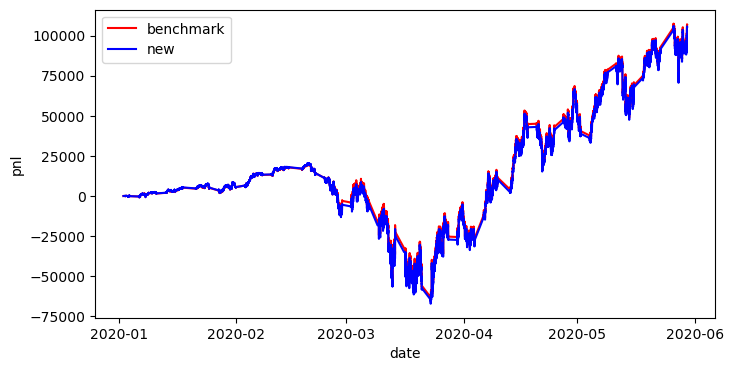

In [24]:
pnl_bench=df['cash'].cumsum()+df['inventory']
pnl_new=df['cash_new'].cumsum()+df['inventory']

plt.figure(figsize=(8,4))
plt.plot(pnl_bench.index,pnl_bench.values,color='red',label='benchmark')
plt.plot(pnl_new.index,pnl_new.values,color='blue',label='new')
plt.xlabel('date')
plt.ylabel('pnl')
plt.legend()
plt.show()